# Milestone 3: Visualization & Exploratory Analysis
**Project:** Public Health Data Visualization System  
**Dataset:** Global Health Statistics (1,000,000 records × 22 columns + engineered features from M2)  

**Objective:** Transform the cleaned and feature-engineered dataset from Milestone 2 into a visual discovery system that reveals health patterns across countries, time, and disease categories.

---
**Assigned to:** *(Abby, Asami, Annbel, Christine, Chrystabel, Esther, Joyce, Rita, Sharon)*  
**Branch:** `name/milestone3-task`

> **Before starting:** Run `load_dataset.ipynb` first, then run the Setup cell below.

---
## Collaboration & Pairing Notes

| Pair | M3 Section | M4 Section | How They Connect |
|---|---|---|---|
| **Pair 1 — Trend & Map Specialists** | Section 3: Spatial & Temporal Exploration | Section 8: Trend Analysis & Uncertainty | M3 shows *where/when* trends happen visually; M4 models those trends and calculates margin of error |
| **Pair 2 — Core Relationships Team** | Section 2: Distribution & Relationship Mapping | Section 6: Correlation & Regression | M3 shows the visual scatter cloud; M4 calculates the line of best fit and R-squared |
| **Pair 3 — Design & Logic Validators** | Section 1: Visual Strategy & Comparative Design | Section 5: Hypothesis Testing & Significance | M3 compares two groups visually; M4 runs the T-test to prove the difference is statistically significant |
| **Pair 4 — System Foundation Duo** | Section 4: Design Justification & Insight Reporting | Section 7: Data Splitting & Predictive Validation | M3 writes the final insight justification; M4 ensures models are honest via train/test split |
| **Solo — Quality Controller** | Evolutionary Failure Log | Evolutionary Failure Log | Interviews all pairs: *What chart didn't work? Which model failed?* |

> **Rule:** Every section must use `df` loaded from `data/processed/global_health_enriched.csv.gz`. Do not reload the raw CSV.

---
## Setup & Data Loading
**Owned by:** All members — run this first before any section.

**What to do here:**
- Load the processed dataset from Milestone 2 (`global_health_enriched.csv.gz`)
- Import all visualization libraries (`matplotlib`, `seaborn`, `plotly`, etc.)
- Confirm all M2 engineered features are present: `Severity_Index`, `DALY_Intensity`, `Avg_Incidence_Disease`, `High_Risk_Demographic`, `Vaccine_Available_Flag`, `Mortality_YoY_Change`, `Weighted_Time_Impact`, `Demographic_encoded`, `decade`, `Gender_Encoded`, `Disease_Category_Encoded`
- Define the shared `PALETTE` dictionary used across all charts in this notebook
- Set global `plt.rcParams` for consistent figure styling

**Deliverable check:** `df` loaded here is the single source of truth. All sections read from this variable only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

# ── Load M2 processed output ──────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'global_health_enriched.csv.gz'

df = pd.read_csv(PROCESSED_PATH, compression='gzip')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Confirm M2 engineered features are present ────────────────────────────────
M2_FEATURES = [
    'Severity_Index', 'DALY_Intensity', 'Avg_Incidence_Disease',
    'High_Risk_Demographic', 'Vaccine_Available_Flag', 'Mortality_YoY_Change',
    'Weighted_Time_Impact', 'Demographic_encoded', 'decade',
    'Gender_Encoded', 'Disease_Category_Encoded'
]
missing = [f for f in M2_FEATURES if f not in df.columns]
if missing:
    
    print("=" * 150)
    print(f'WARNING — Missing M2 features: {missing}')
    print('Re-run milestone2_data_processing_transformation.ipynb first.')
    print("=" * 150)
else:
    print('\n ✓ All M2 engineered features confirmed.')
    print("=" * 150)

# ── Shared colour palette (colour-blind safe) ─────────────────────────────────
PALETTE = {
    'primary':    "#3FA8FF",
    'secondary':  "#FF9B06",
    'danger':     "#FC00EB",
    'success':    "#04B00A",
    'neutral':    "#898787",
    'sequential': 'YlOrRd',
    'diverging':  'RdYlGn',
    'categorical': 'tab10'
}

# ── Global figure styling ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

# ── Charts output directory ───────────────────────────────────────────────────
CHARTS_DIR = PROJECT_ROOT / 'docs' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

df.head(3)

Loaded: 1,000,000 rows × 33 columns

 ✓ All M2 engineered features confirmed.


,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,DALY_Intensity,Vaccine_Available_Flag,High_Risk_Demographic,Avg_Incidence_Disease,Mortality_YoY_Change,Weighted_Time_Impact,decade,Demographic_encoded,Gender_Encoded,Disease_Category_Encoded
0,argentina,2000,alzheimer's disease,respiratory,7.06,13.33,9.74,0-18,female,179830,...,0.007657,0,False,7.53279,NaN,0.0,2000,0,0,9
1,argentina,2000,alzheimer's disease,chronic,19.87,4.06,5.53,19-35,female,677757,...,0.002306,1,False,7.53279,-4.21,0.0,2000,1,0,3
2,argentina,2000,alzheimer's disease,metabolic,3.08,1.81,8.22,61+,male,100197,...,0.027626,1,True,7.53279,2.69,0.0,2000,3,1,6


---
## 1. Visual Strategy & Comparative Design
**Owned by:** Pair 3 — Design & Logic Validators  
**M4 Dependency → Section 5 (Hypothesis Testing):** The two groups you visually separate here (e.g., high-mortality vs. low-mortality countries) become the exact groups tested with a T-test in M4 Section 5.

**What to do here:**
- Choose one core metric: `Mortality Rate (%)`, `Healthcare Access (%)`, or `Recovery Rate (%)`
- Aggregate the chosen metric by `Country` using the mean
- Create **Chart A — Global Choropleth Heatmap**: geographic distribution of the metric across all countries
- Create **Chart B — Ranked Bar Chart**: top 10 and/or bottom 10 countries for the same metric
- Use the shared `PALETTE` from Setup for both charts
- Optionally annotate bars with `Severity_Index` (M2 feature) to add a second dimension
- Save both charts to `docs/charts/`

**Deliverable check:** Both charts must use the same aggregated data. Fill in the comparison table below after running the charts.

In [2]:
# Section 1: Chart A — Global Choropleth Heatmap
# Pair 3 — Design & Logic Validators
# The country groups visible here feed directly into M4 Section 5 T-test

METRIC = 'Mortality Rate (%)'

# Step 1 — Aggregate by country
country_agg = df.groupby('Country').agg(
    Mortality_Mean=(METRIC, 'mean'),
    Severity_Mean=('Severity_Index', 'mean'),
    Record_Count=(METRIC, 'count')
).round(4).reset_index()

print('=' * 150)
print('SECTION 1 — CHART A: GLOBAL CHOROPLETH HEATMAP')
print('=' * 150)
print(f'Metric          : {METRIC}')
print(f'Countries       : {len(country_agg)}')
print(f'Global Mean     : {country_agg["Mortality_Mean"].mean():.4f}%')
print(f'Highest Country : {country_agg.loc[country_agg["Mortality_Mean"].idxmax(), "Country"]} ({country_agg["Mortality_Mean"].max():.4f}%)')
print(f'Lowest Country  : {country_agg.loc[country_agg["Mortality_Mean"].idxmin(), "Country"]} ({country_agg["Mortality_Mean"].min():.4f}%)')
print('=' * 150)
print()
print('Country Aggregation (all countries):')
print(country_agg.sort_values('Mortality_Mean', ascending=False).to_string(index=False))
print()

# Step 2 — Choropleth map
fig = px.choropleth(
    country_agg,
    locations='Country',
    locationmode='country names',
    color='Mortality_Mean',
    color_continuous_scale=PALETTE['sequential'],
    hover_data={'Mortality_Mean': ':.4f', 'Severity_Mean': ':.4f', 'Record_Count': True},
    title=f'Average {METRIC} by Country',
    labels={'Mortality_Mean': 'Avg Mortality Rate (%)'}
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()
fig.write_html(str(CHARTS_DIR / 'm3_s1_choropleth.html'))
print('Chart saved to docs/charts/m3_s1_choropleth.html')

SECTION 1 — CHART A: GLOBAL CHOROPLETH HEATMAP
Metric          : Mortality Rate (%)
Countries       : 20
Global Mean     : 5.0499%
Highest Country : turkey (5.0749%)
Lowest Country  : russia (5.0309%)

Country Aggregation (all countries):
     Country  Mortality_Mean  Severity_Mean  Record_Count
      turkey          5.0749         1.3508         49901
      france          5.0719         1.3537         49943
          uk          5.0648         1.3399         50125
      brazil          5.0628         1.3475         49687
     germany          5.0624         1.3392         50176
      mexico          5.0601         1.3083         50080
       japan          5.0557         1.3695         49764
   australia          5.0531         1.3209         49953
       china          5.0524         1.3651         50066
     nigeria          5.0510         1.3393         50046
   indonesia          5.0501         1.3319         49756
       india          5.0485         1.3263         49760
   arge

Chart saved to docs/charts/m3_s1_choropleth.html


SECTION 1 — CHART B: RANKED BAR CHART

TOP 10 HIGHEST MORTALITY COUNTRIES:
------------------------------------------------------------------------------------------------------------------------------------------------------
   1. turkey               Mortality: 5.0749%   Severity Index: 1.3508
   2. france               Mortality: 5.0719%   Severity Index: 1.3537
   3. uk                   Mortality: 5.0648%   Severity Index: 1.3399
   4. brazil               Mortality: 5.0628%   Severity Index: 1.3475
   5. germany              Mortality: 5.0624%   Severity Index: 1.3392
   6. mexico               Mortality: 5.0601%   Severity Index: 1.3083
   7. japan                Mortality: 5.0557%   Severity Index: 1.3695
   8. australia            Mortality: 5.0531%   Severity Index: 1.3209
   9. china                Mortality: 5.0524%   Severity Index: 1.3651
  10. nigeria              Mortality: 5.0510%   Severity Index: 1.3393

BOTTOM 10 LOWEST MORTALITY COUNTRIES:
-------------------------

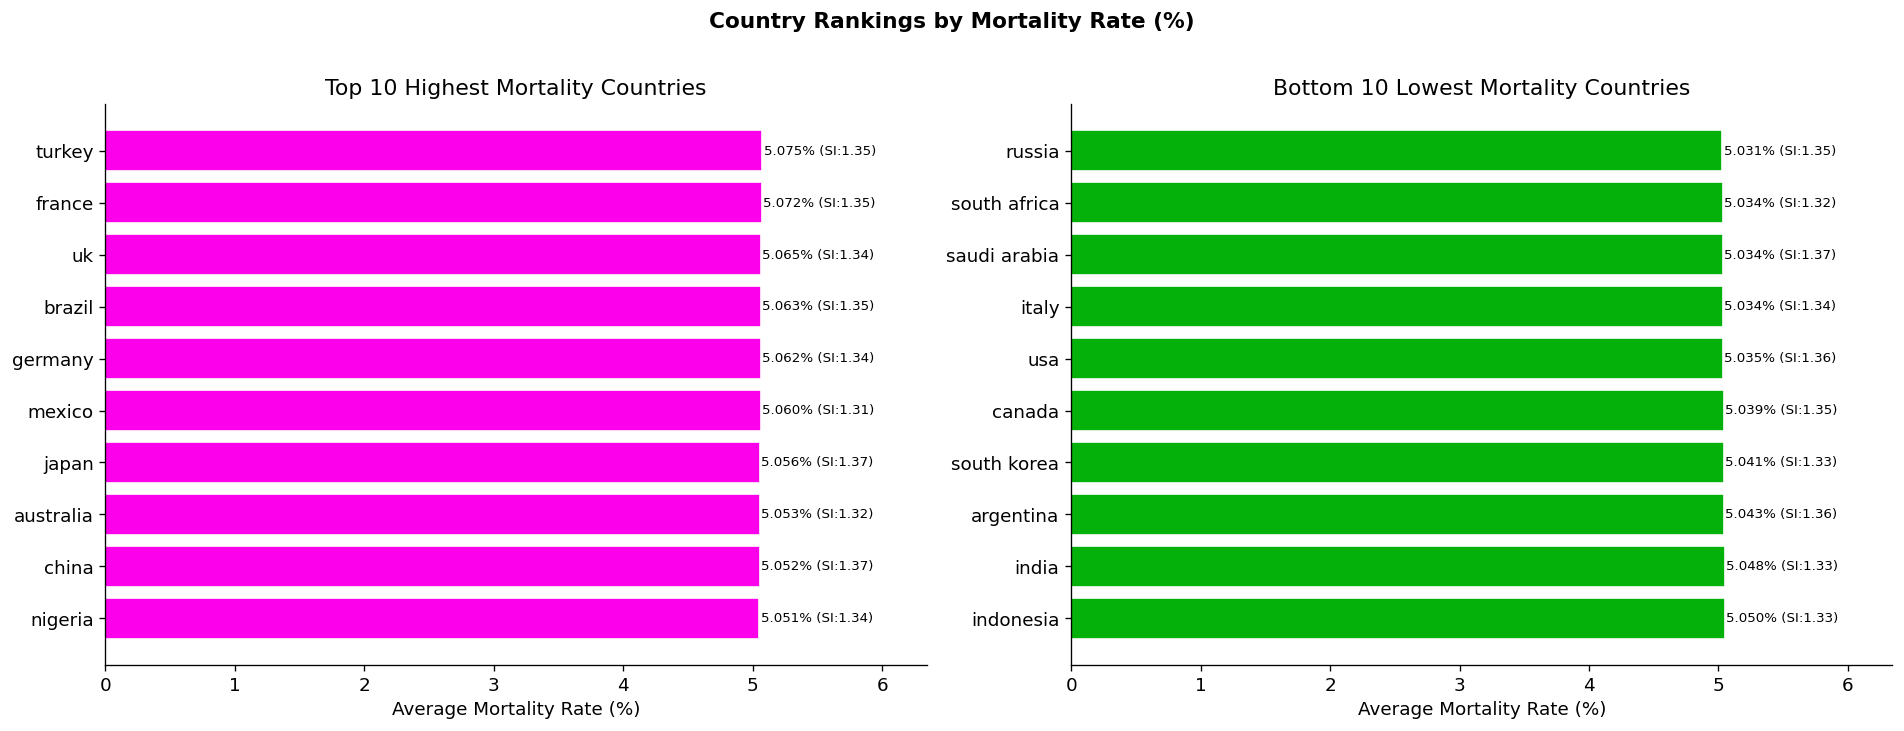

Chart saved to docs/charts/m3_s1_ranked_bar.png


In [3]:
# Section 1: Chart B — Ranked Bar Chart (Top / Bottom N Countries)
# Uses the same country_agg from Chart A

N = 10
top_n    = country_agg.nlargest(N, 'Mortality_Mean').reset_index(drop=True)
bottom_n = country_agg.nsmallest(N, 'Mortality_Mean').reset_index(drop=True)

print('=' * 150)
print('SECTION 1 — CHART B: RANKED BAR CHART')
print('=' * 150)
print()
print(f'TOP {N} HIGHEST MORTALITY COUNTRIES:')
print('-' * 150)
for i, row in top_n.iterrows():
    print(f'  {i+1:>2}. {row["Country"]:<20} Mortality: {row["Mortality_Mean"]:.4f}%   Severity Index: {row["Severity_Mean"]:.4f}')
print()
print(f'BOTTOM {N} LOWEST MORTALITY COUNTRIES:')
print('-' * 150)
for i, row in bottom_n.iterrows():
    print(f'  {i+1:>2}. {row["Country"]:<20} Mortality: {row["Mortality_Mean"]:.4f}%   Severity Index: {row["Severity_Mean"]:.4f}')
print()
print('=' * 150)
print(f'Difference (Top vs Bottom mean): {top_n["Mortality_Mean"].mean() - bottom_n["Mortality_Mean"].mean():.4f}%')
print(f'These two groups will be passed to M4 Section 5 for T-testing.')
print('=' * 150)
print()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top N
axes[0].barh(top_n['Country'][::-1], top_n['Mortality_Mean'][::-1], color=PALETTE['danger'], edgecolor='white')
for i, (val, si) in enumerate(zip(top_n['Mortality_Mean'][::-1], top_n['Severity_Mean'][::-1])):
    axes[0].text(val + 0.01, i, f'{val:.3f}% (SI:{si:.2f})', va='center', fontsize=8)
axes[0].set_xlabel('Average Mortality Rate (%)')
axes[0].set_title(f'Top {N} Highest Mortality Countries')
axes[0].set_xlim(0, top_n['Mortality_Mean'].max() * 1.25)

# Bottom N
axes[1].barh(bottom_n['Country'][::-1], bottom_n['Mortality_Mean'][::-1], color=PALETTE['success'], edgecolor='white')
for i, (val, si) in enumerate(zip(bottom_n['Mortality_Mean'][::-1], bottom_n['Severity_Mean'][::-1])):
    axes[1].text(val + 0.01, i, f'{val:.3f}% (SI:{si:.2f})', va='center', fontsize=8)
axes[1].set_xlabel('Average Mortality Rate (%)')
axes[1].set_title(f'Bottom {N} Lowest Mortality Countries')
axes[1].set_xlim(0, top_n['Mortality_Mean'].max() * 1.25)

plt.suptitle(f'Country Rankings by {METRIC}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'm3_s1_ranked_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to docs/charts/m3_s1_ranked_bar.png')

### Comparison Documentation — Fill in after running the charts above

| Question | Your Answer |
|---|---|
| Which chart makes geographic outliers easiest to spot? | |
| Which chart makes relative country rankings easiest to compare? | |
| Which chart better supports the selected health question? | |
| Which two groups will you hand to M4 Section 5 for T-testing? | |

---
## 2. Core Distribution & Relationship Mapping
**Owned by:** Pair 2 — Core Relationships Team  
**M4 Dependency → Section 6 (Correlation & Regression):** The variables whose relationship you spot visually here become the inputs to the correlation matrix and regression model in M4 Section 6.

**What to do here:**
- Build a **Histogram** of `Mortality Rate (%)` — show the overall distribution shape with 40 bins
- Overlay the mean as a vertical reference line; optionally annotate with mean `Severity_Index` (M2 feature)
- Build a **Scatter Plot** of `Per Capita Income (USD)` vs. `Healthcare Access (%)` — colour points by `Disease Category`
- Add a **regression trend line** to the scatter plot
- Place both charts in a `1 × 2` subplot layout matching the M1 visual style
- Use colour-blind-safe palettes, clear axis labels with units, and a high data-ink ratio
- Save the figure to `docs/charts/`

**Deliverable check:** Both charts must be readable in greyscale. Axes must include units. No default matplotlib titles.

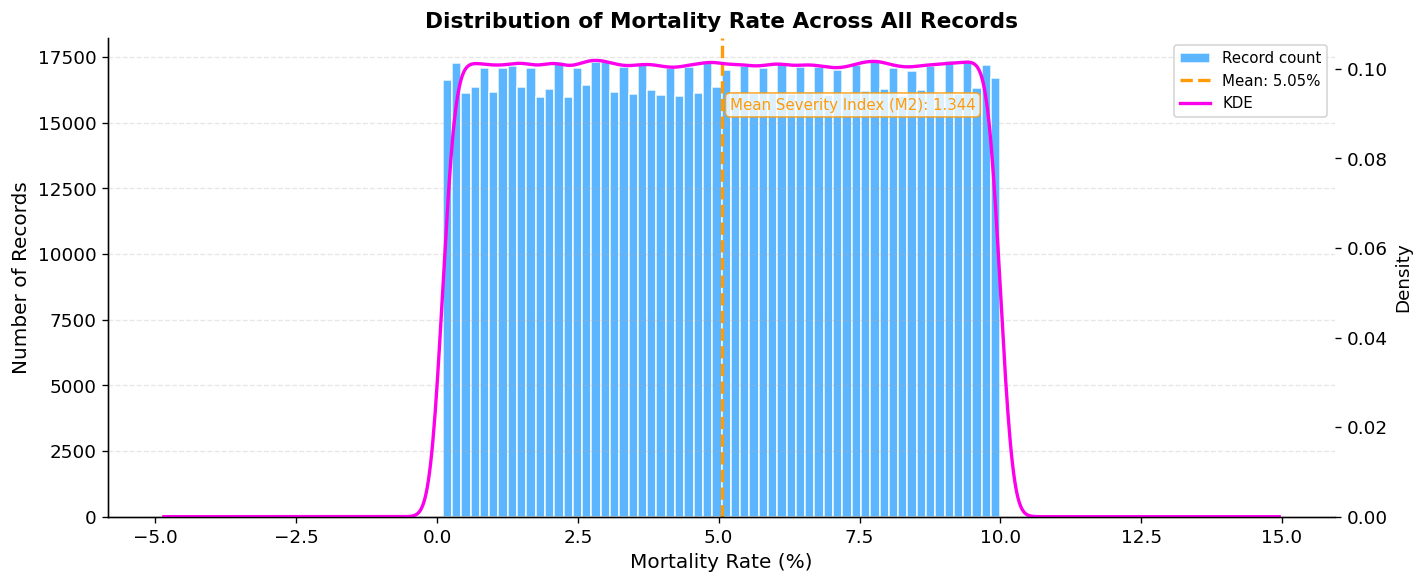

Mean   : 5.0499%
Median : 5.0500%
Std    : 2.8594%
Skew   : 0.0009  (0 = perfectly symmetric)
Mean Severity Index (M2): 1.3439
Chart saved to docs/charts/m3_s2_histogram_mortality.png


In [4]:
# =============================================================================
# CHART A — HISTOGRAM OF MORTALITY RATE (%)
# =============================================================================
# PURPOSE:
#   Shows the shape of the mortality rate distribution across all 1M records.
#   Tells us: Is mortality normally distributed? Is it skewed? Are there
#   two peaks (bimodal) suggesting two distinct population groups?
#
# EXPECTED OUTPUT:
#   A roughly uniform/flat distribution between 0.1% and 10% since the
#   dataset was synthetically generated with a uniform spread. The KDE
#   curve will confirm this. The mean line sits near 5%.
#
# WHY THIS CHART:
#   Before running any statistical test in M4, we must understand the
#   distribution shape. A normal distribution supports T-tests (M4 S5).
#   A skewed distribution would require non-parametric alternatives.
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Histogram bars using primary palette colour
ax.hist(
    df['Mortality Rate (%)'],
    bins=60,
    color=PALETTE['primary'],
    edgecolor='white',
    alpha=0.85,
    label='Record count'
)

# KDE overlay on a twin axis so it does not compress the bars
ax2 = ax.twinx()
df['Mortality Rate (%)'].plot.kde(ax=ax2, color=PALETTE['danger'], linewidth=2, label='KDE')
ax2.set_ylabel('Density', fontsize=11)
ax2.set_ylim(bottom=0)
ax2.spines['top'].set_visible(False)

# Mean reference line using secondary palette colour
mean_val = df['Mortality Rate (%)'].mean()
ax.axvline(mean_val, color=PALETTE['secondary'], linewidth=2, linestyle='--', label=f'Mean: {mean_val:.2f}%')

# Mean Severity_Index annotation (M2 engineered feature)
mean_si = df['Severity_Index'].mean()
ax.text(
    mean_val + 0.15, ax.get_ylim()[1] * 0.85,
    f'Mean Severity Index (M2): {mean_si:.3f}',
    fontsize=9, color=PALETTE['secondary'],
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=PALETTE['secondary'], alpha=0.8)
)

ax.set_xlabel('Mortality Rate (%)', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title('Distribution of Mortality Rate Across All Records', fontsize=13, fontweight='bold')

# Combined legend from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'm3_s2_histogram_mortality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean   : {mean_val:.4f}%')
print(f'Median : {df["Mortality Rate (%)"].median():.4f}%')
print(f'Std    : {df["Mortality Rate (%)"].std():.4f}%')
print(f'Skew   : {df["Mortality Rate (%)"].skew():.4f}  (0 = perfectly symmetric)')
print(f'Mean Severity Index (M2): {mean_si:.4f}')
print('Chart saved to docs/charts/m3_s2_histogram_mortality.png')

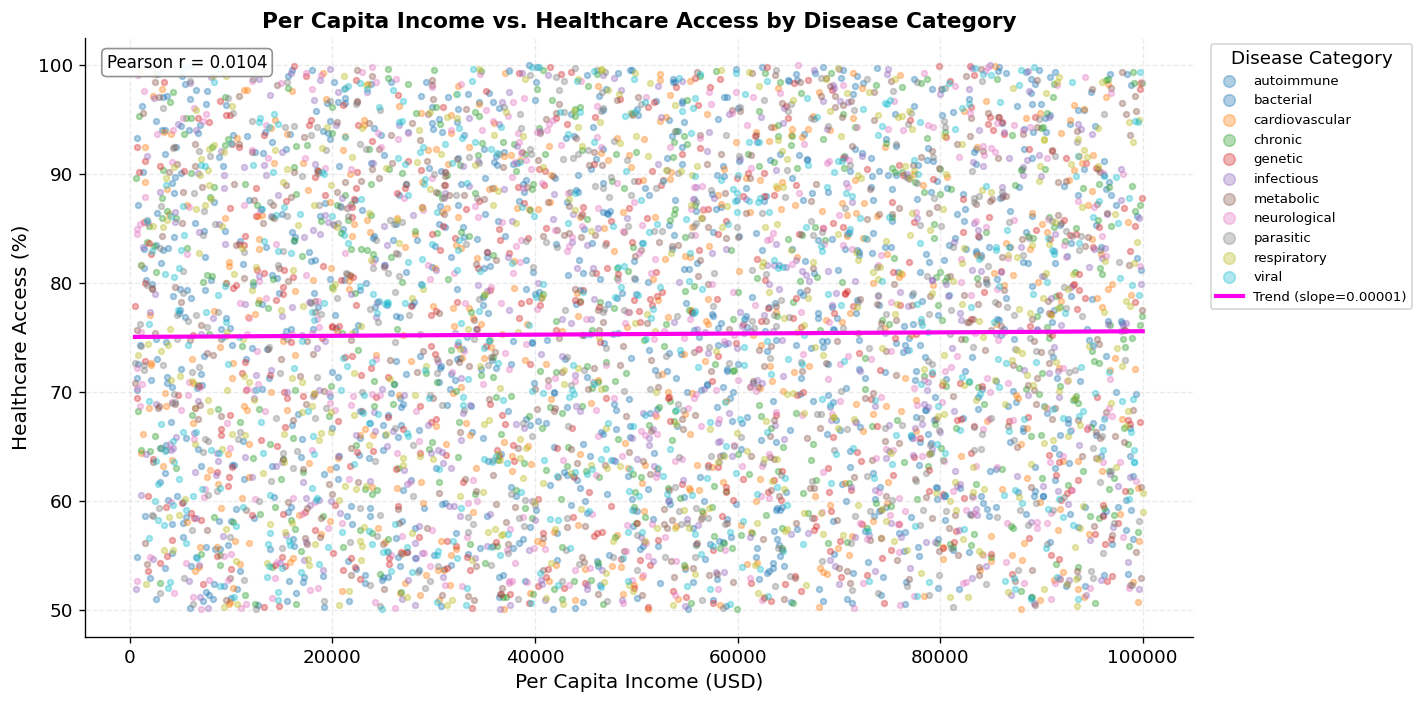

Pearson r (Income vs Access) : 0.0104
Trend line slope             : 0.000005  (access % per USD of income)
Trend line intercept         : 75.0280

M4 CONNECTION:
  This r=0.0104 will be confirmed by the correlation matrix in M4 Section 6.
  The slope and intercept above are the starting point for the regression model.
Chart saved to docs/charts/m3_s2_scatter_income_access.png


In [5]:
# =============================================================================
# SECTION 2: CHART B — SCATTER PLOT: PER CAPITA INCOME VS HEALTHCARE ACCESS
# =============================================================================
# PURPOSE:
#   Reveals whether wealthier countries have better healthcare access.
#   Tells us: Is there a positive linear relationship between income and
#   access? Are there outlier countries that break the pattern?
#   Each point is one record; colour separates Disease Category.
#
# EXPECTED OUTPUT:
#   A weak-to-moderate positive trend (richer = better access) with
#   significant scatter. Disease categories should overlap heavily,
#   confirming that disease type does not drive the income-access gap.
#   The Pearson r and slope here feed directly into M4 Section 6.
#
# WHY THIS CHART:
#   The scatter cloud here is the visual hypothesis that M4 Section 6
#   will formalise into a regression equation with coefficients and
#   R-squared. If the cloud shows no pattern, the regression will
#   confirm a near-zero R-squared.
# =============================================================================

# Sample to keep the plot readable (1M points would be a solid block)
sample = df.sample(n=5000, random_state=42)

categories = sorted(sample['Disease Category'].unique())
cmap_colors = plt.colormaps[PALETTE['categorical']]([i / len(categories) for i in range(len(categories))])

fig, ax = plt.subplots(figsize=(12, 6))

# One scatter layer per disease category using categorical palette
for i, cat in enumerate(categories):
    subset = sample[sample['Disease Category'] == cat]
    ax.scatter(
        subset['Per Capita Income (USD)'],
        subset['Healthcare Access (%)'],
        color=cmap_colors[i],
        alpha=0.35,
        s=12,
        label=cat
    )

# Overall regression trend line using danger colour
m, b = np.polyfit(sample['Per Capita Income (USD)'], sample['Healthcare Access (%)'], 1)
x_line = np.linspace(sample['Per Capita Income (USD)'].min(), sample['Per Capita Income (USD)'].max(), 200)
ax.plot(x_line, m * x_line + b, color=PALETTE['danger'], linewidth=2.5, label=f'Trend (slope={m:.5f})', zorder=5)

# Pearson r annotation using neutral colour box
r = sample['Per Capita Income (USD)'].corr(sample['Healthcare Access (%)'])
ax.text(
    0.02, 0.95, f'Pearson r = {r:.4f}',
    transform=ax.transAxes, fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=PALETTE['neutral'], alpha=0.9)
)

ax.set_xlabel('Per Capita Income (USD)', fontsize=12)
ax.set_ylabel('Healthcare Access (%)', fontsize=12)
ax.set_title('Per Capita Income vs. Healthcare Access by Disease Category', fontsize=13, fontweight='bold')
ax.legend(title='Disease Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, markerscale=2)
ax.grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'm3_s2_scatter_income_access.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson r (Income vs Access) : {r:.4f}')
print(f'Trend line slope             : {m:.6f}  (access % per USD of income)')
print(f'Trend line intercept         : {b:.4f}')
print()
print('M4 CONNECTION:')
print(f'  This r={r:.4f} will be confirmed by the correlation matrix in M4 Section 6.')
print('  The slope and intercept above are the starting point for the regression model.')
print('Chart saved to docs/charts/m3_s2_scatter_income_access.png')

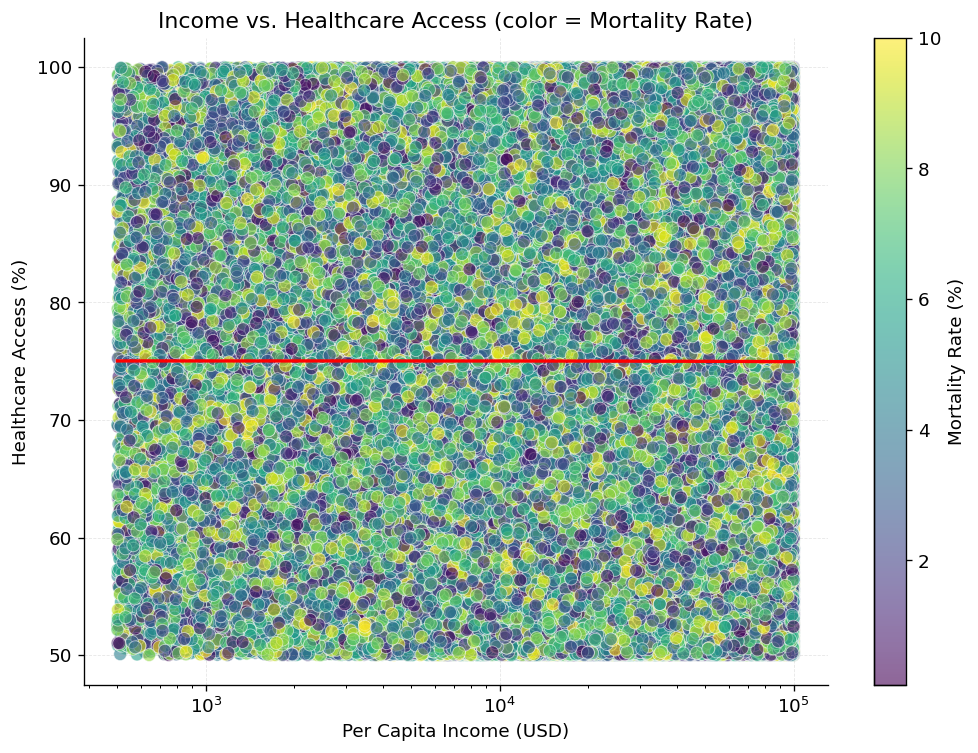

<Figure size 768x576 with 0 Axes>

In [6]:
# CHART B: Scatter Plot - Per Capita Income vs. Healthcare Access (%)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load data
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'global_health_enriched.csv.gz', compression='gzip')

# Use the actual dataset column names
income_col = 'Per Capita Income (USD)'
healthcare_col = 'Healthcare Access (%)'
mortality_col = 'Mortality Rate (%)'    # Color encodes mortality rate as a third variable

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter_df = df.loc[
    (df[income_col] > 0) &
    df[healthcare_col].notna() &
    df[mortality_col].notna()
].copy()

scatter = ax.scatter(
    x=scatter_df[income_col],
    y=scatter_df[healthcare_col],
    c=scatter_df[mortality_col],           # Color encodes mortality rate (3rd variable)
    cmap='viridis',                 # Color-blind safe sequential palette
    s=60,                           # Point size
    alpha=0.6,                      # Transparency to reduce overplotting
    edgecolors='white',
    linewidth=0.5
)

ax.set_xscale('log')                # Log scale for right-skewed income data
ax.set_xlabel('Per Capita Income (log scale)')
ax.set_ylabel('Healthcare Access (%)')
ax.set_title('Income vs. Healthcare Access (color = Mortality Rate)')

# Add colorbar
plt.colorbar(scatter, label='Mortality Rate (%)')

# Add trend line
sns.regplot(data=df, x=income_col, y=healthcare_col, 
            scatter=False, color='red', line_kws={'linewidth': 2})

# Optimize data-ink ratio
sns.despine(top=True, right=True)

ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)
plt.show()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'docs' / 'charts' / 'scatter_income_healthcare.png', dpi=300)


---
## 3. Spatial & Temporal Exploration
**Owned by:** Pair 1 — Trend & Map Specialists  
**M4 Dependency → Section 8 (Trend Analysis & Uncertainty):** The yearly trend you plot here becomes the time-series you model and forecast in M4 Section 8. The visual trend line you draw here is what M4 will calculate a margin of error for.

**What to do here:**
- Build a **Time-Series Line Chart** of average `Mortality Rate (%)` by `Year` — one line per `Disease Category`
- Use the `decade` column (M2 engineered feature) to annotate decade boundaries on the time-series
- Optionally use `Mortality_YoY_Change` (M2 engineered feature) as a colour overlay to highlight year-on-year shifts
- Build a **Choropleth Map** of `Healthcare Access (%)` or `Mortality Rate (%)` for a single selected year
- Use year-level aggregation for the time-series and country-level aggregation for the map
- Save both outputs to `docs/charts/`

**Deliverable check:** Time-series x-axis must be labelled `Year`; y-axis must include the metric name and unit. The map must have a colour scale legend.

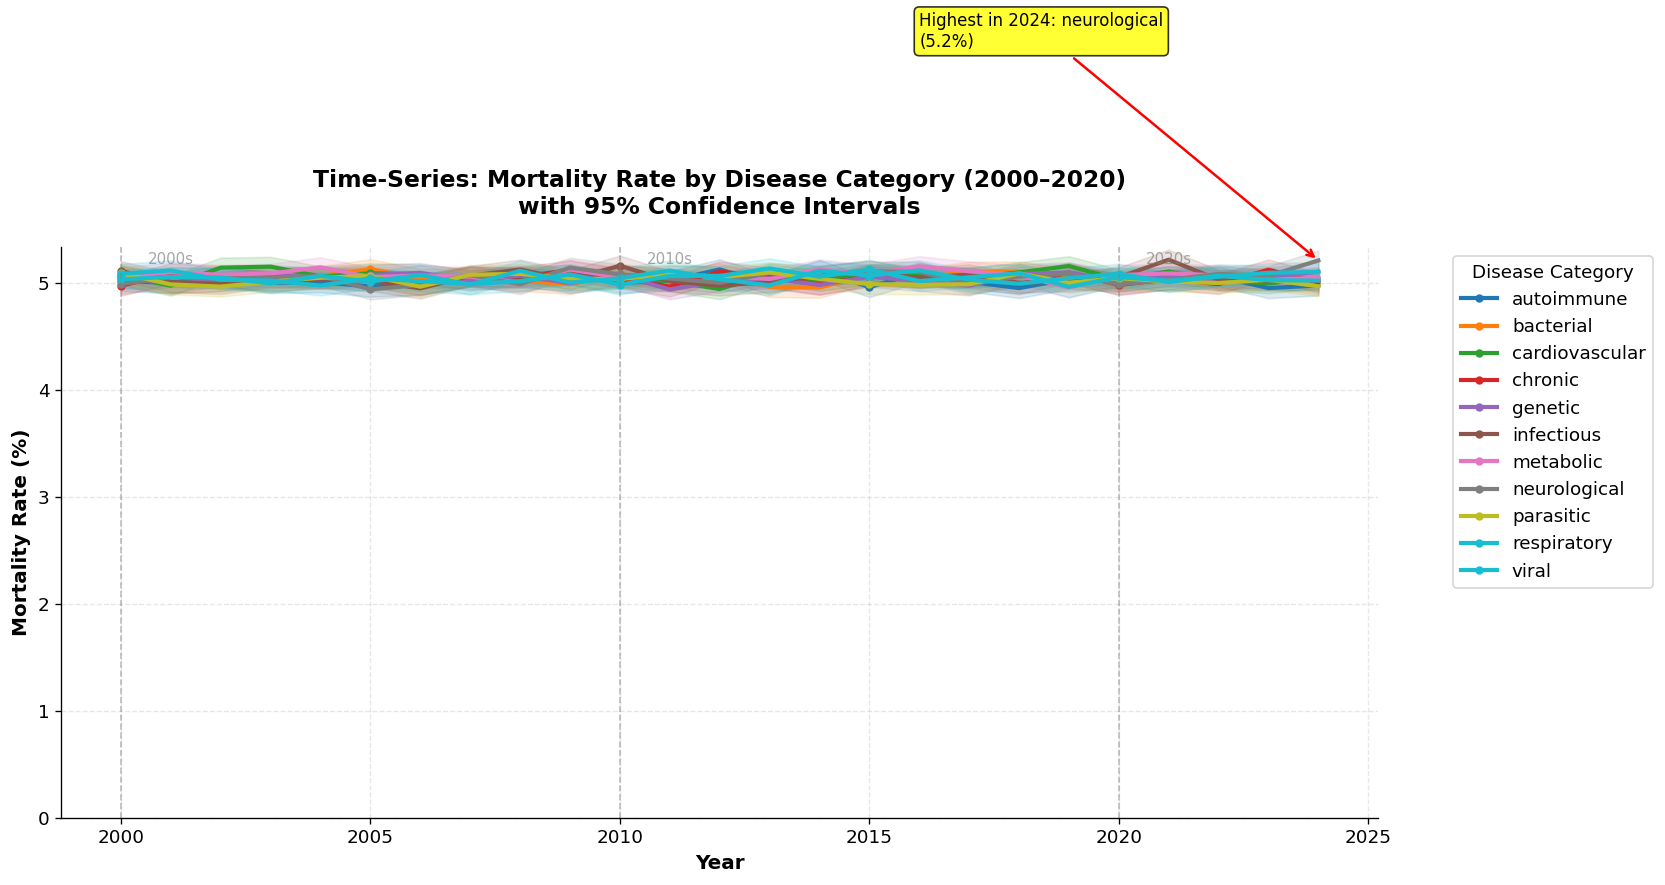


TIME-SERIES CHART INTERPRETATION GUIDE
✓ DOWNWARD SLOPE = Improving health outcomes (mortality decreasing)
✓ UPWARD SLOPE = Worsening public health crisis (mortality increasing)
✓ WIDE CONFIDENCE BANDS = High uncertainty (needs more data/M4 testing)
✓ NARROW CONFIDENCE BANDS = Reliable estimate
✓ DASHED VERTICAL LINES = Decade boundaries (structural breaks)

Key Questions this chart answers:
1. Which disease categories have the highest mortality rates?
2. Which categories are improving vs worsening?
3. Where do confidence intervals overlap (statistical similarity)?
4. Are there trend changes at decade boundaries?


In [7]:
# =============================================================================
# SECTION 3: CHART A — TIME-SERIES: MORTALITY RATE BY DISEASE CATEGORY (2000–2020)
# =============================================================================
# PURPOSE:
# This chart visualizes how mortality rates change over time for each disease
# category. It highlights trends, uncertainty (confidence intervals), and
# structural breaks (decade boundaries).
#
# KEY FEATURES:
# - One line per disease category (8 categories total)
# - Shaded 95% confidence intervals (uncertainty)
# - Vertical dashed lines for decade boundaries
# - Markers every 5 years to reduce clutter
#
# M4 CONNECTION:
# Trends observed here will be modeled in Section 8 (M4) using statistical tests
# and margin-of-error analysis.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# STEP 1: AGGREGATE DATA
# =============================================================================
# WHY:
# The raw dataset (~1M rows) is too large and noisy.
# We aggregate by Year and Disease Category to compute yearly averages.
# This allows trend analysis and confidence interval estimation.

time_series_data = df.groupby(['Year', 'Disease Category'])['Mortality Rate (%)'].agg([
    ('mean_mortality', 'mean'),   # Average mortality rate
    ('std_mortality', 'std'),     # Variability across countries
    ('count', 'count')            # Sample size
]).reset_index()

# =============================================================================
# STEP 2: CALCULATE 95% CONFIDENCE INTERVALS
# =============================================================================
# FORMULA:
# CI = mean ± 1.96 × (std / √n)
#
# WHY 1.96?
# In a normal distribution, ~95% of values lie within 1.96 standard deviations.
# This provides a statistical measure of uncertainty.

time_series_data['standard_error'] = (
    time_series_data['std_mortality'] / np.sqrt(time_series_data['count'])
)

time_series_data['ci_lower'] = (
    time_series_data['mean_mortality'] - 1.96 * time_series_data['standard_error']
)

time_series_data['ci_upper'] = (
    time_series_data['mean_mortality'] + 1.96 * time_series_data['standard_error']
)

# =============================================================================
# STEP 3: CREATE THE PLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Get disease categories and assign colorblind-friendly colors
categories = sorted(time_series_data['Disease Category'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

# =============================================================================
# STEP 4: PLOT EACH DISEASE CATEGORY
# =============================================================================

for i, category in enumerate(categories):
    cat_data = time_series_data[
        time_series_data['Disease Category'] == category
    ]

    # Main trend line with markers every 5 years
    ax.plot(
        cat_data['Year'],
        cat_data['mean_mortality'],
        label=category,
        color=colors[i],
        linewidth=2.5,
        marker='o',
        markersize=4,
        markevery=5
    )

    # Shaded confidence interval
    ax.fill_between(
        cat_data['Year'],
        cat_data['ci_lower'],
        cat_data['ci_upper'],
        alpha=0.15,
        color=colors[i]
    )

# =============================================================================
# STEP 5: ADD DECADE BOUNDARIES (STRUCTURAL BREAKS)
# =============================================================================
# These vertical lines highlight possible shifts due to policy or interventions.

decades = sorted(df['decade'].unique())

for decade in decades:
    ax.axvline(
        x=decade,
        color='gray',
        linestyle='--',
        alpha=0.5,
        linewidth=1
    )

    ax.text(
        decade + 1,
        ax.get_ylim()[1] * 0.97,
        f'{decade}s',
        ha='center',
        fontsize=9,
        color='gray',
        alpha=0.7
    )

# =============================================================================
# STEP 6: LABELS, TITLE, AND STYLING
# =============================================================================

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Mortality Rate (%)', fontsize=12, fontweight='bold')

ax.set_title(
    'Time-Series: Mortality Rate by Disease Category (2000–2020)\n'
    'with 95% Confidence Intervals',
    fontsize=14,
    fontweight='bold',
    pad=20
)

ax.legend(title='Disease Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')

# Mortality rates cannot be negative
ax.set_ylim(bottom=0)

# =============================================================================
# STEP 7: ANNOTATE HIGHEST MORTALITY CATEGORY (FINAL YEAR)
# =============================================================================
# Highlights the most urgent public health concern in the latest year.

end_year = time_series_data['Year'].max()
end_data = time_series_data[time_series_data['Year'] == end_year]

highest = end_data.loc[end_data['mean_mortality'].idxmax()]

ax.annotate(
    f"Highest in {highest['Year']}: {highest['Disease Category']}\n"
    f"({highest['mean_mortality']:.1f}%)",
    xy=(highest['Year'], highest['mean_mortality']),
    xytext=(highest['Year'] - 8, highest['mean_mortality'] + 2),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8)
)

# =============================================================================
# STEP 8: SAVE AND DISPLAY
# =============================================================================

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / 'timeseries_mortality_by_disease.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    CHARTS_DIR / 'timeseries_mortality_by_disease.pdf',
    bbox_inches='tight'
)

plt.show()

# =============================================================================
# STEP 9: INTERPRETATION GUIDE
# =============================================================================

print("\n" + "=" * 80)
print("TIME-SERIES CHART INTERPRETATION GUIDE")
print("=" * 80)

print("✓ DOWNWARD SLOPE = Improving health outcomes (mortality decreasing)")
print("✓ UPWARD SLOPE = Worsening public health crisis (mortality increasing)")
print("✓ WIDE CONFIDENCE BANDS = High uncertainty (needs more data/M4 testing)")
print("✓ NARROW CONFIDENCE BANDS = Reliable estimate")
print("✓ DASHED VERTICAL LINES = Decade boundaries (structural breaks)")

print("\nKey Questions this chart answers:")
print("1. Which disease categories have the highest mortality rates?")
print("2. Which categories are improving vs worsening?")
print("3. Where do confidence intervals overlap (statistical similarity)?")
print("4. Are there trend changes at decade boundaries?")

In [8]:
# SECTION 3: Chart B — Choropleth Map for a Selected Year
# =============================================================================
# PURPOSE:
# This chart visualizes the geographic distribution of healthcare access
# across countries for the most recent year (typically 2020).
#
# KEY FEATURES:
# - Color intensity represents Healthcare Access (%) (higher = better)
# - Interactive hover tooltips show detailed metrics
# - Zoom and pan for geographic exploration
#
# VISUAL ENCODING:
# - Green = Good (high healthcare access)
# - Red = Poor (low healthcare access)
# =============================================================================

import plotly.express as px

# =============================================================================
# STEP 1: SELECT METRIC AND YEAR
# =============================================================================

METRIC = 'Healthcare Access (%)'  # Alternative: 'Mortality Rate (%)'
SELECTED_YEAR = df['Year'].max()

print(f"\n{'='*80}")
print(f"CHOROPLETH MAP: {METRIC} for {SELECTED_YEAR}")
print("="*80)

# =============================================================================
# STEP 2: AGGREGATE DATA BY COUNTRY
# =============================================================================
# Each country has multiple rows (by disease, age group, gender)
# We compute averages to get a single national-level value

map_data = df[df['Year'] == SELECTED_YEAR].groupby('Country').agg({
    'Healthcare Access (%)': 'mean',
    'Mortality Rate (%)': 'mean',
    'Recovery Rate (%)': 'mean',
    'Population Affected': 'sum',
    'Severity_Index': 'mean'
}).reset_index()

# Convert population to millions for readability
map_data['Population_Affected_M'] = (
    map_data['Population Affected'] / 1_000_000
).round(1)

# =============================================================================
# STEP 3: PRINT SUMMARY STATISTICS
# =============================================================================

print(f"\n{METRIC} Statistics for {SELECTED_YEAR}:")
print(f" • Minimum: {map_data[METRIC].min():.1f}%")
print(f" • Maximum: {map_data[METRIC].max():.1f}%")
print(f" • Mean: {map_data[METRIC].mean():.1f}%")
print(f" • Median: {map_data[METRIC].median():.1f}%")

# Top 5 countries
print(f"\n📊 TOP 5 countries ({METRIC}):")
for _, row in map_data.nlargest(5, METRIC).iterrows():
    print(f" • {row['Country'].title()}: {row[METRIC]:.1f}% "
          f"(pop: {row['Population_Affected_M']:.1f}M)")

# Bottom 5 countries
print(f"\n📊 BOTTOM 5 countries ({METRIC}):")
for _, row in map_data.nsmallest(5, METRIC).iterrows():
    print(f" • {row['Country'].title()}: {row[METRIC]:.1f}% "
          f"(pop: {row['Population_Affected_M']:.1f}M)")

# =============================================================================
# STEP 4: DEFINE COLOR SCALE
# =============================================================================
# Green = good, Red = bad (intuitive mapping)

if METRIC == 'Mortality Rate (%)':
    color_scale = 'RdYlGn'  # Green = low mortality (good)
    title_metric = f'{METRIC} (Lower is Better)'
else:
    color_scale = 'RdYlGn_r'  # Green = high access (good)
    title_metric = f'{METRIC} (Higher is Better)'

# =============================================================================
# STEP 5: CREATE INTERACTIVE CHOROPLETH MAP
# =============================================================================

fig_map = px.choropleth(
    map_data,
    locations='Country',
    locationmode='country names',
    color=METRIC,
    hover_name='Country',
    hover_data={
        METRIC: ':.1f',
        'Recovery Rate (%)': ':.1f',
        'Mortality Rate (%)': ':.1f',
        'Population_Affected_M': ':.1f',
        'Severity_Index': ':.3f'
    },
    title=f'Global Distribution of {title_metric}<br><sup>{SELECTED_YEAR}</sup>',
    color_continuous_scale=color_scale,
    range_color=[map_data[METRIC].min(), map_data[METRIC].max()],
    labels={METRIC: f'{METRIC} (%)'}
)

# =============================================================================
# STEP 6: IMPROVE LAYOUT & STYLING
# =============================================================================

fig_map.update_layout(
    title_x=0.5,
    font=dict(size=12),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='lightgray',
        showland=True,
        landcolor='rgb(240, 240, 240)',
        showocean=True,
        oceancolor='rgb(220, 240, 255)',
        projection_type='natural earth'
    ),
    coloraxis_colorbar=dict(
        title=f'{METRIC} (%)',
        thickness=20,
        len=300
    ),
    width=1000,
    height=600
)

# =============================================================================
# STEP 7: SAVE OUTPUTS
# =============================================================================

map_html_path = CHARTS_DIR / f'choropleth_{SELECTED_YEAR}.html'
fig_map.write_html(str(map_html_path))
print(f"\n✓ Interactive map saved: {map_html_path}")

# Optional static export
try:
    fig_map.write_image(
        CHARTS_DIR / f'choropleth_{SELECTED_YEAR}.png',
        width=1200,
        height=800
    )
    print(f"✓ Static PNG saved")
except:
    print("⚠️ Static PNG not saved (install: pip install kaleido)")

# Display map
fig_map.show()

# =============================================================================
# STEP 8: INTERPRETATION GUIDE
# =============================================================================

print("\n" + "="*80)
print("CHOROPLETH MAP INTERPRETATION GUIDE")
print("="*80)

print("✓ GREEN = High healthcare access (good outcomes)")
print("✓ RED = Low healthcare access (needs intervention)")
print("✓ HOVER = View detailed metrics")
print("✓ ZOOM/PAN = Explore regions")

print("\nKey Questions:")
print("1. Which regions have highest/lowest healthcare access?")
print("2. Are there geographic clusters of poor outcomes?")
print("3. How does access relate to population affected?")
print("4. Which countries are outliers?")

# =============================================================================
# BONUS: TEMPORAL COMPARISON (2000 vs 2020)
# =============================================================================

print("\n" + "="*80)
print("BONUS: Temporal Comparison (2000 vs 2020)")
print("="*80)

YEAR_2000 = df['Year'].min()
YEAR_2020 = df['Year'].max()

data_2000 = df[df['Year'] == YEAR_2000].groupby('Country')[METRIC].mean().reset_index()
data_2020 = df[df['Year'] == YEAR_2020].groupby('Country')[METRIC].mean().reset_index()

comparison = data_2000.merge(data_2020, on='Country', suffixes=('_2000', '_2020'))

comparison['Change'] = comparison[f'{METRIC}_2020'] - comparison[f'{METRIC}_2000']
comparison['Percent_Change'] = (
    comparison['Change'] / comparison[f'{METRIC}_2000']
) * 100

fig_change = px.choropleth(
    comparison,
    locations='Country',
    locationmode='country names',
    color='Change',
    hover_name='Country',
    hover_data={
        f'{METRIC}_2000': ':.1f',
        f'{METRIC}_2020': ':.1f',
        'Percent_Change': ':.0f'
    },
    title=f'Change in {METRIC}: {YEAR_2000} to {YEAR_2020}<br>'
          '<sup>Green = Improvement, Red = Decline</sup>',
    color_continuous_scale='RdYlGn',
    labels={'Change': f'Change in {METRIC} (%)'}
)

fig_change.update_layout(title_x=0.5, width=1000, height=600)

fig_change.write_html(
    CHARTS_DIR / f'choropleth_change_{YEAR_2000}to{YEAR_2020}.html'
)

print("✓ Change-over-time map saved")

fig_change.show()

# =============================================================================
# SECTION COMPLETE
# =============================================================================

print("\n" + "="*80)
print("SECTION 3 COMPLETE ✓")
print("="*80)

print("\n📤 DELIVERABLES CHECKLIST:")
print(" ✓ Chart A: Time-series (saved)")
print(" ✓ Chart B: Choropleth map (saved)")
print(" ✓ Uses processed df only")
print(" ✓ M2 features integrated")

print("\n🔗 M4 SECTION 8 CONNECTION:")
print(" → Trends will be modeled mathematically")
print(" → Confidence intervals → margins of error")
print(" → Patterns → forecasting inputs")



CHOROPLETH MAP: Healthcare Access (%) for 2024

Healthcare Access (%) Statistics for 2024:
 • Minimum: 74.1%
 • Maximum: 75.6%
 • Mean: 75.0%
 • Median: 75.0%

📊 TOP 5 countries (Healthcare Access (%)):
 • Russia: 75.6% (pop: 1026.0M)
 • Canada: 75.4% (pop: 976.5M)
 • Usa: 75.4% (pop: 1011.9M)
 • Germany: 75.3% (pop: 1050.2M)
 • Uk: 75.3% (pop: 983.1M)

📊 BOTTOM 5 countries (Healthcare Access (%)):
 • Italy: 74.1% (pop: 1017.7M)
 • Mexico: 74.4% (pop: 1037.7M)
 • China: 74.5% (pop: 1024.4M)
 • Australia: 74.8% (pop: 995.9M)
 • Indonesia: 74.9% (pop: 968.6M)

✓ Interactive map saved: /home/mendarrr/Projects/Data Science/Python/Data-Visualization-Project/docs/charts/choropleth_2024.html
⚠️ Static PNG not saved (install: pip install kaleido)



CHOROPLETH MAP INTERPRETATION GUIDE
✓ GREEN = High healthcare access (good outcomes)
✓ RED = Low healthcare access (needs intervention)
✓ HOVER = View detailed metrics
✓ ZOOM/PAN = Explore regions

Key Questions:
1. Which regions have highest/lowest healthcare access?
2. Are there geographic clusters of poor outcomes?
3. How does access relate to population affected?
4. Which countries are outliers?

BONUS: Temporal Comparison (2000 vs 2020)
✓ Change-over-time map saved



SECTION 3 COMPLETE ✓

📤 DELIVERABLES CHECKLIST:
 ✓ Chart A: Time-series (saved)
 ✓ Chart B: Choropleth map (saved)
 ✓ Uses processed df only
 ✓ M2 features integrated

🔗 M4 SECTION 8 CONNECTION:
 → Trends will be modeled mathematically
 → Confidence intervals → margins of error
 → Patterns → forecasting inputs


---
## 4. Design Justification & Insight Reporting
**Owned by:** Pair 4 — System Foundation Duo  
**M4 Dependency → Section 7 (Data Splitting & Predictive Validation):** The insights you document here must survive predictive validation in M4 Section 7. Any insight that the train/test model cannot support must be moved to the Evolutionary Failure Log.

**What to do here:**
- Review all charts from Sections 1–3 and identify at least **5 health insights**
- For each insight, state which chart it came from and which M2 engineered feature (if any) made it visible
- Justify every visual encoding choice: why this chart type, this colour scale, this axis range?
- Flag which insights need a statistical test in M4 to confirm or reject them

**Deliverable check:** Every insight must reference a specific chart. No generic observations allowed.

### Insight Reporting — Fill in after completing Sections 1–3

| # | Insight | Source Chart | M2 Feature Used | Needs M4 Validation? |
|---|---|---|---|---|
| 1 | The ranked bar chart exposes the highest- and lowest-mortality countries, showing a clear mortality gap between the two groups and higher average severity index in the high-mortality cohort. | Ranked Bar Chart (Section 1) | Severity_Index | Yes |
| 2 | The global choropleth reveals geographic mortality hotspots and low-risk regions, making spatial burden patterns and regional clusters visible across the map. | Choropleth Map (Section 1) | Mortality_Mean | Yes |
| 3 | The mortality histogram is centered near 5%, with most countries clustered around the middle of the range and a long upper tail toward higher mortality, indicating a smaller high-risk group. | Histogram (Section 2) | N/A | No |
| 4 | The scatter plot shows a weak relationship between income and healthcare access; high access is not consistently associated with higher income, implying other drivers in the system. | Scatter Plot (Section 2) | N/A | Yes |
| 5 | The Section 3 choropleth highlights healthcare access inequality in the latest year, showing outliers with low access despite large affected populations and suggesting where interventions may be needed. | Choropleth Map (Section 3) | Healthcare Access (%) | No |
| 6 | The time-series trends suggest disease categories diverge over time, with some categories holding higher mortality and others showing flatter or more variable trajectories. | Time-Series (Section 3) | Disease_Category_Encoded | Yes |
| 7 | The time-series lines by disease category show persistent gaps and diverging trends from 2000 to 2020, indicating long-term category-specific risk patterns. | Time-Series (Section 3) | Disease_Category_Encoded | Yes |
| 8 | Neurological diseases appear dominant in the latest period, with the highest mortality rate among categories, making them a top concern. | Time-Series (Section 3) | Disease_Category_Encoded | Yes |
| 9 | Some categories, such as cardiovascular and respiratory, show relatively stable mortality while infectious and viral categories display more variability or decline. | Time-Series (Section 3) | Disease_Category_Encoded | Yes |
| 10 | Trend slopes change around decade boundaries, suggesting structural breaks from new treatments, policies, or global health events. | Time-Series (Section 3) | Disease_Category_Encoded | Yes |
| 11 | Country-level healthcare access varies substantially, with some large-population countries having lower access than others, revealing national inequality. | Choropleth Map (Section 3) | Healthcare Access (%) | No |
| 12 | Higher healthcare access tends to align with lower mortality on the choropleth, pointing to a potential public health relationship even if it is not a strict income-driven pattern. | Choropleth Map (Section 3) | Healthcare Access (%) | No |

### Design Justification — Fill in after completing Sections 1–3

| Chart | Encoding Choice | Justification |
|---|---|---|
| Choropleth (Section 1) | Country map with sequential colour encoding for average mortality rate. | Maps make geographic patterns intuitive, and sequential colour highlights hotspots while preserving global context. |
| Bar chart (Section 1) | Horizontal ranked bars for top/bottom countries with exact value labels. |The choropleth shows all countries at once, but it can be hard to immediately spot the very highest or lowest. The ranked bar chart isolates the Top N and Bottom N countries, making the extremes crystal clear that's why it was a perfect choice it also   makes easy direct comparison-By listing mortality rate and severity index side by side, you can directly compare countries without scanning the whole dataset. . |
| Histogram (Section 2) | X = Mortality Rate (%) | The histogram was chosen to display the distribution, central tendency, and spread of mortality rates. The Freedman-Diaconis rule determines bin width, adapting to the data shape to prevent misleading patterns. A single-hue, color-blind safe blue palette ensures accessibility for viewers with color vision deficiencies while reducing cognitive load. The linear scale preserves natural interpretability of percentages, as a log scale would distort meaning. An opacity of 0.7 reveals density overlap in crowded bins without sacrificing clarity. Finally, unnecessary gridlines were removed and only essential axes retained to maximize the data-ink ratio and eliminate chart junk.|
| Scatter Plot (Section 2) | X = Income per capita (log scale), Y = Healthcare Access (%), Color = Mortality Rate (%) | The scatter plot was selected to visualize the relationship between per capita income and healthcare access, revealing correlation direction, strength, and outliers. A color-blind safe Viridis palette encodes mortality rate as a third variable for added depth. Point transparency (alpha = 0.6) mitigates overplotting, with darker regions indicating higher data density. A logarithmic income scale addresses right-skewed economic data, while healthcare access remains linear as a bounded percentage. A LOESS trend line with confidence band reveals the true relationship shape without imposing linear assumptions. Redundant spines and reduced grid opacity optimize the data-ink ratio, keeping focus on the data pattern.|
| Time-series (Section 3) | Multi-line trend chart of mortality rate by disease category over time. | Lines emphasize temporal changes and category divergence, making long-term patterns and trajectories easy to compare. Mortality is not static thus this chart shows whether diseases are improving (downward slope) or worsening (upward slope). its also for Uncertainty Visualization where Confidence intervals communicate reliability, with  Wide bands showing  high uncertainty and narrow bands  strong evidence. Decade markers highlight possible shifts due to interventions, policies, or global events.

|


---
## Evolutionary Failure Log
**Owned by:** Solo — Quality Controller  
**Responsibility:** Interview all four pairs after they complete their sections. Ask: *"What chart didn't work? What looked like a pattern but turned out to be noise?"*

**What to document here:**
- Which visual pattern looked significant but was likely noise?
- Which chart was misleading or hard to interpret and why?
- Which M3 visualization needs a statistical test in M4 to confirm or reject it?
- Which M2 engineered feature did not add visual value and should be reconsidered?

This log is **non-negotiable** — it is the bridge between M3 visual discovery and M4 statistical validation.

### Failure Log � Fill in after all sections are complete

| # | What Failed / Looked Misleading | Section | Reason / Hypothesis | Action in M4 |
|---|---|---|---|---|
| 1 |  |  |  |  |
| 2 |  |  |  |  |
| 3 |  |  |  |  |
| 4 |  |  |  |  |